In [6]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [7]:
import zipfile

zip_ref = zipfile.ZipFile('archive (2).zip', 'r')
zip_ref.extractall()
zip_ref.close()

In [8]:
dataset_path = "/content/brain_tumor_dataset"

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

model = models.Sequential([

    layers.Input(shape=(224,224,3)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.7044 - loss: 0.6197 - val_accuracy: 0.7400 - val_loss: 0.5259
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.7931 - loss: 0.4984 - val_accuracy: 0.7400 - val_loss: 0.5102
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.8276 - loss: 0.4233 - val_accuracy: 0.7400 - val_loss: 0.5283
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8621 - loss: 0.3604 - val_accuracy: 0.7800 - val_loss: 0.5418
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8522 - loss: 0.3796 - val_accuracy: 0.8000 - val_loss: 0.4372
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.9064 - loss: 0.2661 - val_accuracy: 0.8400 - val_loss: 0.3878
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.9261 - loss: 0.2020 - val_accuracy: 0.8400 - val_loss: 0.4831
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - a

In [13]:
model.build((None,224,224,3))

In [18]:
import numpy as np
model.predict(np.zeros((1,224,224,3)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


array([[0.5003908]], dtype=float32)

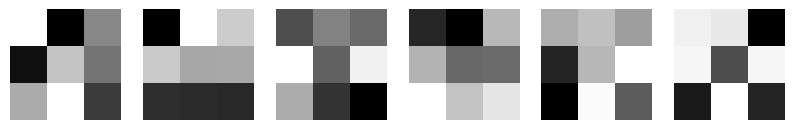

In [23]:
filters, biases = model.layers[0].get_weights()

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

n_filters = 6
plt.figure(figsize=(10,5))

for i in range(n_filters):

    f = filters[:,:,:,i]

    plt.subplot(1,n_filters,i+1)
    plt.imshow(f[:,:,0], cmap='gray')
    plt.axis('off')

plt.show()

In [24]:
img_path = "/content/brain_tumor_dataset/yes/Y1.jpg"

img = tf.keras.preprocessing.image.load_img(img_path,target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)
img_array = img_array/255.0

In [40]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    last_conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[last_conv_layer.output, model.layers[-1].output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:,0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [41]:
for layer in model.layers:
    print(layer.name)

conv2d_3
max_pooling2d_3
conv2d_4
max_pooling2d_4
conv2d_5
max_pooling2d_5
flatten_1
dense_2
dropout_1
dense_3


In [42]:
model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


array([[0.9998427]], dtype=float32)

In [43]:
model.build((None, 224, 224, 3))

In [44]:
heatmap = make_gradcam_heatmap(img_array, model, "conv2d_5")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_13']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


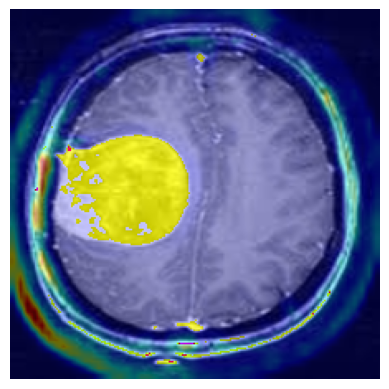

In [45]:
# first call the model
model.predict(img_array)

# then GradCAM
heatmap = make_gradcam_heatmap(img_array, model, "conv2d_5")

img = cv2.imread(img_path)
img = cv2.resize(img,(224,224))

heatmap = cv2.resize(heatmap,(224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"),cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()